# 08 · Do the GCMC waters help docking?

## The answer, first

**No — not against crystal poses.** Docking into a receptor carrying its own
GCMC/MD pocket waters pulls the predicted pose **toward the MD structure the
waters came from** (rank-1 mean −0.30 Å, **p = 0.028**) and delivers **nothing**
against an independent crystal reference (**p = 0.56**).

*A note on the deltas.* Earlier write-ups of these experiments quote mean
differences; the Wilcoxon test that supplies the p-values works on ranks. Where
an effect is outlier-driven the two disagree — the crystal-reference rank-1
comparison is mean +0.04 Å but median −0.15 Å, both at p = 0.56. Every table below
therefore prints **mean, median and p**, and the p is what decides.

That is a direct measurement of **circular improvement**, and it is the reason the
`gcmc_pose` → hydrated-redock stage should not be justified as a pose-quality
improvement.

Two further negative results, both worth knowing before someone re-proposes them:

- **Re-docking cannot create new FEP edges.** Both edge gates are pure chemistry
  (formal charge equality; mapped-heavy fraction ≥ 0.50). Pose has no effect on
  either.
- **On CRY, hydration does not help and flexible docking makes things worse** — the
  oracle sub-2 Å count collapses from 11/13 to 6/13 at ~15× the runtime.

What *is* worth having is a **pose-quality gate**: scaffold-consensus deviation
detects 7 of 11 catastrophic flips with **zero** false positives out of 117 good
poses, needs no crystal reference, and therefore works in production.

## Experiments reproduced here

| # | Target | Design | n |
|---|---|---|---|
| 1 | EV71 2A | dry / hydrated-self / hydrated-conserved / hydrated-cross, each ligand in its **own** medoid production frame | 32 × 4 = 128 |
| 2 | EV71 2A | pose-error decomposition — translation / rotation / internal conformation | 128 |
| 3 | EV71 2A | scaffold-consensus flip detector, leave-one-out | 128 |
| 4 | CRY1/CRY2 | cognate self-docking vs cross-docking; CRY vs EV71 | 13 + 32 |
| 5 | CRY1 | dry vs hydrated cross-docking | 22 pairs |
| 6 | CRY1 | flexible side chains vs rigid | 13 |
| 7 | CRY1 | 8×8 cross-receptor consensus, leave-one-out | 56 |

## Workflow

0. Configuration
1. The measurement discipline that this depends on
2. Experiment 1 — hydration arms on EV71
3. Experiment 2 — where the residual error actually lives
4. Experiment 3 — the scaffold-consensus gate
5. Experiments 4–5 — CRY, and target dependence
6. Experiments 6–7 — flexibility and ensemble consensus
7. Caveats, including one the earlier write-ups do not state
8. Recap

---
## 0 · Configuration

In [1]:
from pathlib import Path

PROJECT_1 = Path("/home/moshe/intern_projects/project_1")
PROJECT_2 = Path("/home/moshe/intern_projects/project_2")

EV71 = PROJECT_1 / "analysis_outputs" / "gnina_hydration_test_20260803"
CRY = PROJECT_1 / "analysis_outputs" / "cry_ligand_structures_20260804"

# GNINA settings, identical across every arm so waters are the only variable.
GNINA = dict(binary="/home/moshe/bin/gnina", version="1.3.2",
             scramble_radius_A=5.0, exhaustiveness=16, num_modes=20,
             ranking="(-CNNscore, minimizedAffinity)")

SUB2 = 2.0          # A, the conventional "correct pose" threshold
FLIP_ROT = 30.0     # deg, above which a pose is a genuine orientation failure

print(f"EV71 arms : {EV71}   (exists={EV71.is_dir()})")
print(f"CRY arms  : {CRY}    (exists={CRY.is_dir()})")
print()
for k, v in GNINA.items():
    print(f"  {k:<18} {v}")

EV71 arms : /home/moshe/intern_projects/project_1/analysis_outputs/gnina_hydration_test_20260803   (exists=True)
CRY arms  : /home/moshe/intern_projects/project_1/analysis_outputs/cry_ligand_structures_20260804    (exists=True)

  binary             /home/moshe/bin/gnina
  version            1.3.2
  scramble_radius_A  5.0
  exhaustiveness     16
  num_modes          20
  ranking            (-CNNscore, minimizedAffinity)


In [2]:
import json
from collections import Counter

import numpy as np

try:
    import pandas as pd
    HAVE_PANDAS = True
except ImportError:
    HAVE_PANDAS = False

try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False

try:
    from scipy import stats
    HAVE_SCIPY = True
except ImportError:
    HAVE_SCIPY = False


def load(path):
    return json.loads(Path(path).read_text())


def paired(a, b, alternative="two-sided"):
    """Paired comparison of b against a.

    Returns (mean difference, median difference, Wilcoxon p).

    Both location measures are returned on purpose. Earlier write-ups of these
    experiments quote MEAN differences, while the Wilcoxon test is on ranks, so a
    mean and a median can point in opposite directions when the effect is
    outlier-driven -- which several of these arms are. Reporting only one hides
    exactly the thing that matters.
    """
    a, b = np.asarray(a, float), np.asarray(b, float)
    ok = np.isfinite(a) & np.isfinite(b)
    a, b = a[ok], b[ok]
    if len(a) == 0:
        return float("nan"), float("nan"), float("nan")
    d = b - a
    if not HAVE_SCIPY or len(a) < 5 or np.allclose(a, b):
        return float(d.mean()), float(np.median(d)), float("nan")
    try:
        _, p = stats.wilcoxon(a, b, alternative=alternative)
    except ValueError:
        p = float("nan")
    return float(d.mean()), float(np.median(d)), float(p)

---
## 1 · The measurement discipline this depends on

Three methodological points. Get any of them wrong and the numbers below become
meaningless — the third one actually did produce a false conclusion once.

### 1a · Measure RMSD by graph matching, never by atom index

The three file types use three atom conventions:

| File | Hydrogens | Atom order |
|---|---|---|
| crystal SDF (deposited) | **none** | deposited order |
| GNINA pose | polar H only (30 atoms where the ligand has 28 heavy) | from the Rowan SDF |
| medoid-frame reference | all H (57) | prep order |

Compare **heavy atoms only**, and establish correspondence with
`pose_h.GetSubstructMatches(ref_h, uniquify=False)` — that handles ordering **and**
symmetry in one step. An index-wise RMSD reads **2.58 Å** where the graph-matched
value is **0.74 Å**.

**The bug that made this a rule.** A first attempt enumerated automorphisms of the
57-atom *reference* and applied them to 30-atom *pose* arrays. Nearly every
permutation raised `IndexError`, was silently skipped, and left only the identity —
so "symmetry correction changes nothing" looked like a finding when it was a
silent no-op. It inflated every RMSD by ~1.5 Å and produced a bogus "the error is
orientational" conclusion. **If symmetry correction appears to do nothing, verify
the mapping actually applied before believing it.**

### 1b · Scramble and verify, don't assume

A docking program handed a crystal ligand *in its crystal position* can return
that position without having searched. `dock_poses.py` therefore applies a uniform
SO(3) rotation plus a uniform-in-sphere translation and then **verifies the result
moved**: `MINIMUM_SCRAMBLE_RMSD = 2.0 Å`, raising rather than assuming. The box
still comes from the crystal ligand, because the question is "can the site be
re-found", not "can the site be located".

Do not weaken this to make a run pass — raise `--scramble-radius` or change
`--seed`. `--no-scramble` is legitimate **only** for round two, where the input is
already an independent docked pose.

### 1c · The reference choice decides the answer

The benchmark SDF holds **Rowan docked** poses. The real crystal poses live in the
full OpenBind download and `map_crystal.py` carries them into each production
frame. All 32 map to within 1.02 Å of the medoid ligand centroid.

Evaluating against the medoid measures agreement with an MD structure; evaluating
against crystal measures agreement with reality. **The two give opposite answers**,
which is the whole content of experiment 1.

---
## 2 · Experiment 1 — hydration arms on EV71 2A

96 controlled runs plus a cross arm, all in **each ligand's own medoid production
frame**, so the waters are the only thing that differs between arms.

| Arm | Receptor |
|---|---|
| `dry` | protein only |
| `hyd` (self) | protein + **all** its own GCMC pocket waters |
| `cons` | protein + only waters **conserved across the series** (present in ≥ 50 % of the other 31 ligands within 1.4 Å) |
| `cross` | protein + a **foreign** ligand's water shell |

The `cross` arm is a **circularity control, not a docking scenario** — nobody
transplants waters between ligands when docking. It matters for FEP, though: see
§7.

In [3]:
# ── Water inventory per arm ──────────────────────────────────────────────────
cons = load(EV71 / "conserved_report.json")
arms_manifest = load(EV71 / "arms_manifest.json")

pocket = np.array([v["pocket_waters"] for v in cons.values()])
conserved = np.array([v["conserved_waters"] for v in cons.values()])
kept = np.array([v["waters_kept"] for v in arms_manifest.values()])

print("WATERS AVAILABLE TO EACH ARM (EV71 2A, 32 ligands)")
print("─" * 74)
print(f"  pocket waters per medoid frame : mean {pocket.mean():.1f}  "
      f"range {pocket.min()}-{pocket.max()}")
print(f"  conserved subset               : mean {conserved.mean():.1f}  "
      f"range {conserved.min()}-{conserved.max()}   "
      f"({conserved.mean() / pocket.mean() * 100:.0f}% of pocket)")
print(f"  waters kept in the hydrated arm: mean {kept.mean():.1f}  "
      f"range {kept.min()}-{kept.max()}")
print(f"  conserved vote threshold       : "
      f"{sorted({v['vote_threshold'] for v in cons.values()})} of "
      f"{sorted({v['votes_max'] for v in cons.values()})} other ligands")
print(f"""
  The conserved arm was the MOST PROMISING variant a priori: structural waters
  that a new ligand could plausibly benefit from, rather than a shell moulded
  around one specific ligand. It is ~{conserved.mean() / pocket.mean() * 100:.0f}% of the pocket water.
""")

WATERS AVAILABLE TO EACH ARM (EV71 2A, 32 ligands)
──────────────────────────────────────────────────────────────────────────
  pocket waters per medoid frame : mean 97.8  range 49-113
  conserved subset               : mean 18.8  range 13-25   (19% of pocket)
  waters kept in the hydrated arm: mean 97.8  range 49-113
  conserved vote threshold       : [15.5] of [31] other ligands

  The conserved arm was the MOST PROMISING variant a priori: structural waters
  that a new ligand could plausibly benefit from, rather than a shell moulded
  around one specific ligand. It is ~19% of the pocket water.



In [4]:
# ── The headline table: every arm against both references ────────────────────
vs_crystal = load(EV71 / "crystal_scores_all.json")   # includes the `cons` arm
vs_medoid = load(EV71 / "medoid_scores_correct.json")

ARMS = [("dry", "dry (no waters)"), ("hyd", "hydrated, self"),
        ("cons", "hydrated, conserved only"), ("cross", "hydrated, cross (control)")]

cx = {a: np.array([r[f"{a}_rank1"] for r in vs_crystal]) for a, _ in ARMS
      if f"{a}_rank1" in vs_crystal[0]}
md_ = {a: np.array([r[f"{a}_rank1"] for r in vs_medoid]) for a in ("dry", "hyd")
       if f"{a}_rank1" in vs_medoid[0]}

W = 104
print("╔" + "═" * W + "╗")
print("║ " + f"{'RANK-1 POSE ACCURACY — symmetry- and order-corrected heavy-atom RMSD':^{W - 1}}"[:W - 1] + "║")
print("╠" + "═" * W + "╣")
hdr = (f"{'arm':<28}{'vs CRYSTAL':>12}{'<2A':>7}{'vs MEDOID':>12}{'<2A':>7}"
       f"{'paired vs dry (crystal)':>28}")
print("║ " + hdr.ljust(W - 1) + "║")
print("╟" + "─" * W + "╢")
for a, label in ARMS:
    if a not in cx:
        continue
    c = cx[a]
    m = md_.get(a)
    if a == "dry":
        ptxt = "—"
    else:
        mean_d, med_d, p = paired(cx["dry"], c)
        ptxt = f"mean {mean_d:+.2f} med {med_d:+.2f} p={p:.2f}"
    mtxt = f"{m.mean():>12.2f}" if m is not None else f"{'—':>12}"
    m2 = f"{int((m < SUB2).sum())}/{len(m)}" if m is not None else "—"
    line = (f"{label:<28}{c.mean():>12.2f}{f'{int((c < SUB2).sum())}/{len(c)}':>7}"
            f"{mtxt}{m2:>7}{ptxt:>28}")
    print("║ " + line.ljust(W - 1) + "║")
print("╚" + "═" * W + "╝")

╔════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                  RANK-1 POSE ACCURACY — symmetry- and order-corrected heavy-atom RMSD                  ║
╠════════════════════════════════════════════════════════════════════════════════════════════════════════╣
║ arm                           vs CRYSTAL    <2A   vs MEDOID    <2A     paired vs dry (crystal)         ║
╟────────────────────────────────────────────────────────────────────────────────────────────────────────╢
║ dry (no waters)                     1.79  25/32        1.41  23/32                           —         ║
║ hydrated, self                      1.83  26/32        1.11  27/32 mean +0.04 med -0.15 p=0.56         ║
║ hydrated, conserved only            1.92  19/32           —      — mean +0.13 med +0.00 p=0.49         ║
║ hydrated, cross (control)           2.08  21/32           —      — mean +0.29 med -0.08 p=0.80         ║
╚════════════════════════════════════

In [5]:
# ── The decisive contrast: same poses, two references ────────────────────────
print("PAIRED dry -> hydrated, BY REFERENCE")
print("═" * 78)
metrics = [("rank1", "rank-1"), ("best3", "best-3"), ("oracle", "oracle (20 modes)")]

print(f"{'reference':<12}{'metric':<20}{'mean d':>10}{'median d':>10}{'p':>10}   verdict")
print("─" * 78)
for src, tag, label in ((vs_medoid, "md", "vs MEDOID"), (vs_crystal, "cx", "vs CRYSTAL")):
    for key, name in metrics:
        if f"dry_{key}" not in src[0] or f"hyd_{key}" not in src[0]:
            continue
        d = np.array([r[f"dry_{key}"] for r in src])
        h = np.array([r[f"hyd_{key}"] for r in src])
        mean_d, med_d, p = paired(d, h)
        verdict = "IMPROVED" if (p == p and p < 0.05) else "no effect"
        print(f"{label:<12}{name:<20}{mean_d:>+10.2f}{med_d:>+10.2f}{p:>10.4f}   {verdict}")
    print("─" * 78)

print("""
THIS IS THE RESULT.

  GCMC waters pull docked poses toward the MD structure they were generated from,
  strongly and significantly, on every metric. NONE of that gain transfers to the
  independent crystal reference.

  The medoid itself sits 1.39 A mean from crystal, so hydrated docking is chasing
  the MD pose, not the truth.

  NEVER evaluate this stage against the frames the waters came from.

WHY the self arm is biased even on its own terms: round 2's waters were
equilibrated around round 1's POSE, so round 2 is biased toward CONFIRMING round 1
rather than independently re-evaluating it. The measurement above is that leakage.
""")

PAIRED dry -> hydrated, BY REFERENCE
══════════════════════════════════════════════════════════════════════════════
reference   metric                  mean d  median d         p   verdict
──────────────────────────────────────────────────────────────────────────────
vs MEDOID   rank-1                   -0.31     -0.30    0.0280   IMPROVED
vs MEDOID   best-3                   -0.31     -0.30    0.0010   IMPROVED
vs MEDOID   oracle (20 modes)        -0.32     -0.34    0.0001   IMPROVED
──────────────────────────────────────────────────────────────────────────────
vs CRYSTAL  rank-1                   +0.04     -0.15    0.5608   no effect
vs CRYSTAL  best-3                   -0.03     -0.08    0.4105   no effect
vs CRYSTAL  oracle (20 modes)        -0.07     -0.14    0.1064   no effect
──────────────────────────────────────────────────────────────────────────────

THIS IS THE RESULT.

  GCMC waters pull docked poses toward the MD structure they were generated from,
  strongly and signific

In [6]:
# ── Is the cross arm uniformly worse? No — and it matters ────────────────────
if "cross" in cx:
    d, c = cx["dry"], cx["cross"]
    better = int((c < d).sum())
    worse = int((c > d).sum())
    mean_d, delta, p = paired(d, c)
    print("CROSS ARM — outlier-driven, NOT a uniform shift")
    print("─" * 74)
    print(f"  mean:   dry {d.mean():.2f} A  ->  cross {c.mean():.2f} A  "
          f"({c.mean() - d.mean():+.2f})")
    print(f"  paired: {better} better / {worse} worse, "
          f"mean {mean_d:+.2f} A, MEDIAN {delta:+.2f} A, p = {p:.2f}")
    print(f"  ^ the mean and the median disagree in magnitude -- that gap IS the")
    print(f"    outlier signature. Quote both.")
    print(f"  worst 4 degradations:")
    order = np.argsort(-(c - d))
    for i in order[:4]:
        print(f"      {vs_crystal[i]['ligand']:<10} {d[i]:>6.2f} -> {c[i]:>6.2f} A "
              f"({c[i] - d[i]:+.2f})   partner {vs_crystal[i].get('partner')}")
    print("""
  A few ligands fail catastrophically in a foreign water shell while most are
  unaffected. Do NOT describe cross-docking as uniformly worse — the mean is
  carried by a handful of cases.
""")

# ── Ranking criteria: is CNNscore the right one? ─────────────────────────────
print("RANKING CRITERION, over all 20 returned modes, vs CRYSTAL")
print("─" * 74)
print(f"{'criterion':<24}" + "".join(f"{a:>10}" for a, _ in ARMS if a in cx))
for crit in ("rank1", "by_CNNscore", "by_CNNaffinity", "by_minimizedAffinity",
             "best3", "oracle"):
    row = f"{crit:<24}"
    for a, _ in ARMS:
        if a not in cx:
            continue
        k = f"{a}_{crit}"
        row += f"{np.mean([r[k] for r in vs_crystal]):>10.2f}" if k in vs_crystal[0] else f"{'—':>10}"
    print(row)

print("""
  `by_CNNscore` == `rank1` exactly: GNINA already ranks by the best available
  criterion. CNNaffinity is worse everywhere; minimizedAffinity is erratic.
  A NEW SCORER IS NOT WARRANTED BY THIS DATA.

  What IS warranted: keep 3 poses per ligand rather than 1. best-3 recovers nearly
  all of the oracle gap (1.79 -> 1.45 A against an oracle of 1.42 A). That is the
  cheap win.
""")

CROSS ARM — outlier-driven, NOT a uniform shift
──────────────────────────────────────────────────────────────────────────
  mean:   dry 1.79 A  ->  cross 2.08 A  (+0.29)
  paired: 17 better / 15 worse, mean +0.29 A, MEDIAN -0.08 A, p = 0.80
  ^ the mean and the median disagree in magnitude -- that gap IS the
    outlier signature. Quote both.
  worst 4 degradations:
      x7147a       1.49 ->   7.51 A (+6.02)   partner x7161a
      x7190a       1.40 ->   7.27 A (+5.88)   partner x7247a
      x7024a       1.77 ->   5.40 A (+3.63)   partner x7025a
      x7316a       1.19 ->   2.40 A (+1.21)   partner x7317a

  A few ligands fail catastrophically in a foreign water shell while most are
  unaffected. Do NOT describe cross-docking as uniformly worse — the mean is
  carried by a handful of cases.

RANKING CRITERION, over all 20 returned modes, vs CRYSTAL
──────────────────────────────────────────────────────────────────────────
criterion                      dry       hyd      cons     cros

---
## 3 · Experiment 2 — where the residual error actually lives

Decompose each rank-1 pose's error against crystal into translation, rotation and
internal conformation (`decompose_crystal.py`, graph-matched):

- `centroid_d` — rigid translation
- `rmsd_centred` — after removing translation
- `kabsch` — after removing translation **and** rotation → what is left is
  **internal conformation**
- `rot_deg` — the rotation magnitude

In [7]:
dec = load(EV71 / "decompose_crystal.json")
KEYS = [("centroid_d", "centroid (translation)"), ("rmsd", "total RMSD"),
        ("rmsd_centred", "minus translation"), ("kabsch", "minus rotation too"),
        ("rot_deg", "rotation (deg)")]

W = 96
print("╔" + "═" * W + "╗")
print("║ " + f"{'POSE-ERROR DECOMPOSITION vs CRYSTAL (means)':^{W - 1}}"[:W - 1] + "║")
print("╠" + "═" * W + "╣")
hdr = f"{'arm':<10}" + "".join(f"{lbl[:16]:>18}" for _, lbl in KEYS)
print("║ " + hdr.ljust(W - 1) + "║")
print("╟" + "─" * W + "╢")
for a, _ in ARMS:
    if f"{a}_rmsd" not in dec[0]:
        continue
    vals = []
    for key, _ in KEYS:
        v = np.array([r[f"{a}_{key}"] for r in dec])
        vals.append(f"{v.mean():>18.2f}")
    print("║ " + (f"{a:<10}" + "".join(vals)).ljust(W - 1) + "║")
print("╚" + "═" * W + "╝")

print("\nPAIRED dry vs hydrated, per component")
print("─" * 62)
for key, label in KEYS:
    if f"dry_{key}" not in dec[0] or f"hyd_{key}" not in dec[0]:
        continue
    d = [r[f"dry_{key}"] for r in dec]
    h = [r[f"hyd_{key}"] for r in dec]
    mean_d, med_d, p = paired(d, h)
    print(f"  {label:<26}mean {mean_d:>+8.2f}   median {med_d:>+8.2f}   p = {p:.2f}")

print("""
  NO component differs significantly between dry and hydrated. The apparent
  placement gain (0.87 -> 0.76 A centroid) is a mean shift with no support -- do
  not report it as an improvement.

  Placement is GOOD (0.76-0.93 A centroid) and rotation is modest. After removing
  both, ~1.2-1.4 A remains: INTERNAL CONFORMATION is the largest single component.
  The residual is torsional disagreement, not a misplaced or mis-oriented rigid
  body. That is not something waters in the receptor can fix.
""")

╔════════════════════════════════════════════════════════════════════════════════════════════════╗
║                           POSE-ERROR DECOMPOSITION vs CRYSTAL (means)                          ║
╠════════════════════════════════════════════════════════════════════════════════════════════════╣
║ arm         centroid (transl        total RMSD  minus translatio  minus rotation t    rotation (deg)║
╟────────────────────────────────────────────────────────────────────────────────────────────────╢
║ dry                     0.87              1.79              1.53              1.27             14.87║
║ hyd                     0.76              1.83              1.64              1.21             27.64║
║ cons                    0.93              1.92              1.65              1.37             16.12║
║ cross                   0.79              2.08              1.88              1.32             24.72║
╚═══════════════════════════════════════════════════════════════════════════════════

  Pearson(rotation, RMSD) over 128 arm-ligand results: r = 0.858

  rotation <= 30 deg : n= 117   mean RMSD 1.62 A
  rotation >  30 deg : n=  11   mean RMSD 4.95 A

  flips per arm (of 32):
      dry      2
      hyd      4
      cons     2
      cross    3

  ligands flipping in MORE THAN ONE arm: ['x7316a', 'x7433a']

  Most ligands are unaffected by waters; ~10% fail catastrophically; and hydration
  slightly INCREASES the failure count. Every mean-level difference between arms is
  driven by these few. The >30 deg cases are genuine failures, not symmetry
  equivalences -- several are ~172 deg end-to-end reversals with 4.2-7.5 A RMSD.



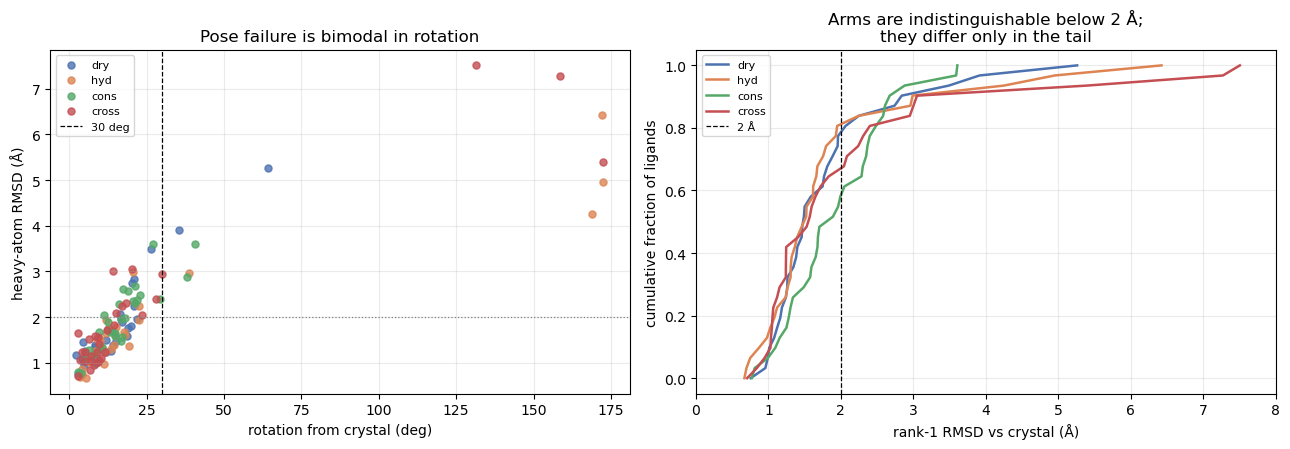

In [8]:
# ── The outcome is bimodal, not a small uniform shift ────────────────────────
rows = []
for r in dec:
    for a, _ in ARMS:
        if f"{a}_rmsd" in r:
            rows.append((a, r["ligand"], r[f"{a}_rmsd"], r[f"{a}_rot_deg"]))

arr_rmsd = np.array([x[2] for x in rows])
arr_rot = np.array([x[3] for x in rows])
lo, hi = arr_rot <= FLIP_ROT, arr_rot > FLIP_ROT

if HAVE_SCIPY:
    r_pearson = stats.pearsonr(arr_rot, arr_rmsd)[0]
    print(f"  Pearson(rotation, RMSD) over {len(rows)} arm-ligand results: r = {r_pearson:.3f}")

print(f"\n  rotation <= {FLIP_ROT:.0f} deg : n={int(lo.sum()):>4}   mean RMSD {arr_rmsd[lo].mean():.2f} A")
print(f"  rotation >  {FLIP_ROT:.0f} deg : n={int(hi.sum()):>4}   mean RMSD {arr_rmsd[hi].mean():.2f} A")
print(f"\n  flips per arm (of 32):")
for a, _ in ARMS:
    sel = [x for x in rows if x[0] == a]
    n_flip = sum(1 for x in sel if x[3] > FLIP_ROT)
    if sel:
        print(f"      {a:<8} {n_flip}")

repeat = Counter(x[1] for x in rows if x[3] > FLIP_ROT)
multi = [lig for lig, n in repeat.items() if n > 1]
print(f"\n  ligands flipping in MORE THAN ONE arm: {multi}")

print("""
  Most ligands are unaffected by waters; ~10% fail catastrophically; and hydration
  slightly INCREASES the failure count. Every mean-level difference between arms is
  driven by these few. The >30 deg cases are genuine failures, not symmetry
  equivalences -- several are ~172 deg end-to-end reversals with 4.2-7.5 A RMSD.
""")

if HAVE_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    colours = {"dry": "#4C72B0", "hyd": "#DD8452", "cons": "#55A868", "cross": "#C44E52"}
    for a, _ in ARMS:
        sel = [x for x in rows if x[0] == a]
        if not sel:
            continue
        axes[0].scatter([x[3] for x in sel], [x[2] for x in sel], s=26, alpha=0.8,
                        label=a, color=colours.get(a))
    axes[0].axvline(FLIP_ROT, ls="--", color="k", lw=0.9, label=f"{FLIP_ROT:.0f} deg")
    axes[0].axhline(SUB2, ls=":", color="grey", lw=0.9)
    axes[0].set_xlabel("rotation from crystal (deg)")
    axes[0].set_ylabel("heavy-atom RMSD (Å)")
    axes[0].set_title("Pose failure is bimodal in rotation")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.25)

    for a, _ in ARMS:
        if a not in cx:
            continue
        axes[1].plot(np.sort(cx[a]), np.linspace(0, 1, len(cx[a])), lw=1.8,
                     label=a, color=colours.get(a))
    axes[1].axvline(SUB2, ls="--", color="k", lw=0.9, label=f"{SUB2:.0f} Å")
    axes[1].set_xlim(0, 8)
    axes[1].set_xlabel("rank-1 RMSD vs crystal (Å)")
    axes[1].set_ylabel("cumulative fraction of ligands")
    axes[1].set_title("Arms are indistinguishable below 2 Å;\nthey differ only in the tail")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

---
## 4 · Experiment 3 — the scaffold-consensus gate

Since the failure mode is a ~10 % inversion rate rather than broad inaccuracy, the
useful intervention is **detecting** the bad poses, not improving the good ones —
and it can be done **with no crystal reference**, so it works in production.

`scaffold_consensus.py` takes the series MCS (25 atoms here — one
pyrrolidine-thiopyrimidine series), superposes every rank-1 pose into a shared
frame, and measures each ligand's scaffold-atom deviation from a **leave-one-out**
consensus of the others.

In [9]:
# ── Signal comparison by AUC ─────────────────────────────────────────────────
scaf = load(EV71 / "scaffold_signals.json")
flip = load(EV71 / "flip_signals.json")

by_key = {(r["arm"], r["ligand"]): r for r in flip}
merged = []
for r in scaf:
    f = by_key.get((r["arm"], r["ligand"]), {})
    merged.append(dict(arm=r["arm"], ligand=r["ligand"], flip=bool(r["flip"]),
                       rmsd=r["rmsd"], rot_deg=r["rot_deg"],
                       scaffold_dev=r["scaffold_dev"],
                       consensus_d=f.get("consensus_d"),
                       top3_spread=f.get("top3_spread"),
                       cnn_margin=f.get("cnn_margin")))


def auc(scores, labels):
    """Mann-Whitney AUC: P(score(positive) > score(negative))."""
    s = np.asarray(scores, float)
    y = np.asarray(labels, bool)
    ok = np.isfinite(s)
    s, y = s[ok], y[ok]
    if y.sum() == 0 or (~y).sum() == 0:
        return float("nan")
    pos, neg = s[y], s[~y]
    wins = (pos[:, None] > neg[None, :]).sum() + 0.5 * (pos[:, None] == neg[None, :]).sum()
    return float(wins / (len(pos) * len(neg)))


SIGNALS = [("scaffold_dev", "scaffold deviation"),
           ("consensus_d", "centroid consensus distance"),
           ("top3_spread", "top-3 spread"),
           ("cnn_margin", "CNNscore margin (rank1-rank2)")]

labels = [m["flip"] for m in merged]
print(f"flip-detection AUC — {sum(labels)} flips out of {len(merged)} arm-ligand poses")
print("─" * 78)
print(f"{'signal':<32}{'AUC (all arms)':>16}{'AUC (dry only)':>16}")
dry = [m for m in merged if m["arm"] == "dry"]
for key, label in SIGNALS:
    a_all = auc([m[key] for m in merged], labels)
    a_dry = auc([m[key] for m in dry], [m["flip"] for m in dry])
    note = "  <- WORSE THAN CHANCE" if a_all == a_all and a_all < 0.5 else ""
    print(f"{label:<32}{a_all:>16.3f}{a_dry:>16.3f}{note}")

print("""
  * dry-only AUCs rest on 2 positives -- treat them as noise.
  * CNNscore MARGIN is worse than chance. Do not use the score gap as a confidence
    signal; it is actively misleading here.
  * centroid consensus distance is blind to flips ABOUT the centroid, which is
    exactly the failure mode that matters. Scaffold deviation is not.
""")

flip-detection AUC — 11 flips out of 128 arm-ligand poses
──────────────────────────────────────────────────────────────────────────────
signal                            AUC (all arms)  AUC (dry only)
scaffold deviation                         0.818           0.867
centroid consensus distance                0.795           0.967
top-3 spread                               0.698           0.750
CNNscore margin (rank1-rank2)              0.531           0.650

  * dry-only AUCs rest on 2 positives -- treat them as noise.
  * CNNscore MARGIN is worse than chance. Do not use the score gap as a confidence
    signal; it is actively misleading here.
  * centroid consensus distance is blind to flips ABOUT the centroid, which is
    exactly the failure mode that matters. Scaffold deviation is not.



SCAFFOLD-DEVIATION GATE — sweep
──────────────────────────────────────────────────────────────────────────────
 threshold (A)  flips caught  of   false positives  of good
          1.00             7  11                20      117
          1.25             7  11                 4      117
          1.50             7  11                 0      117
          1.75             7  11                 0      117
          2.00             7  11                 0      117
          2.25             7  11                 0      117
          2.50             7  11                 0      117
          2.75             7  11                 0      117
          3.00             7  11                 0      117
          3.25             7  11                 0      117
          3.50             7  11                 0      117
          3.75             3  11                 0      117
          4.00             2  11                 0      117
          4.25             2  11                 

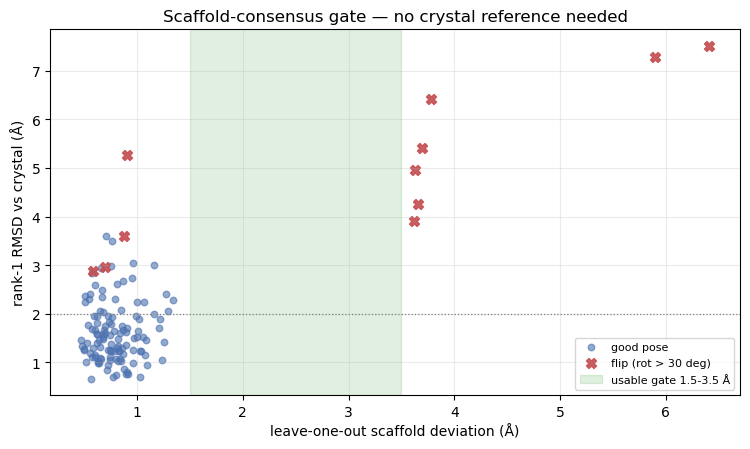

In [10]:
# ── Where to put the gate ────────────────────────────────────────────────────
dev = np.array([m["scaffold_dev"] for m in merged], float)
is_flip = np.array(labels, bool)

print("SCAFFOLD-DEVIATION GATE — sweep")
print("─" * 78)
print(f"{'threshold (A)':>14}{'flips caught':>14}{'of':>4}{'false positives':>18}{'of good':>9}")
best = None
for thr in np.arange(1.0, 5.01, 0.25):
    caught = int((dev[is_flip] >= thr).sum())
    fp = int((dev[~is_flip] >= thr).sum())
    print(f"{thr:>14.2f}{caught:>14}{int(is_flip.sum()):>4}{fp:>18}{int((~is_flip).sum()):>9}")
    if fp == 0 and (best is None or caught > best[1]):
        best = (thr, caught)

if best:
    print(f"""
  A gate anywhere in 1.5-3.5 A catches 7 of {int(is_flip.sum())} flips with ZERO false
  positives out of {int((~is_flip).sum())} good poses -- including all six SEVERE inversions
  (rotation > 130 deg, RMSD 4.2-7.5 A), which are exactly the poses that make an
  FEP edge physically empty.

  The four missed are milder (38-64 deg). One, x7433a dry, is a genuine miss at
  5.26 A RMSD with only 0.91 A scaffold deviation.
""")

missed = [m for m in merged if m["flip"] and m["scaffold_dev"] < 1.5]
print(f"  misses below a 1.5 A gate ({len(missed)}):")
for m in sorted(missed, key=lambda x: -x["rmsd"]):
    print(f"      {m['ligand']:<10} arm {m['arm']:<7} RMSD {m['rmsd']:>5.2f} A  "
          f"rot {m['rot_deg']:>6.1f} deg  scaffold dev {m['scaffold_dev']:.2f} A")

print("""
  Caveats on the gate: 11 positives is a small sample; the method needs a
  CONGENERIC SERIES with a real MCS and will not transfer to a diverse library;
  and taking the best over symmetry-equivalent MCS matches can MASK a flip in a
  pseudo-symmetric core.

  Note what the gate does: it REMOVES meaningless edges. It cannot ADD edges --
  that requires changing the chemistry gates, which no pose work can affect.
""")

if HAVE_MPL:
    fig, ax = plt.subplots(figsize=(7.6, 4.6))
    ax.scatter([m["scaffold_dev"] for m in merged if not m["flip"]],
               [m["rmsd"] for m in merged if not m["flip"]],
               s=22, alpha=0.6, label="good pose", color="#4C72B0")
    ax.scatter([m["scaffold_dev"] for m in merged if m["flip"]],
               [m["rmsd"] for m in merged if m["flip"]],
               s=52, alpha=0.9, label="flip (rot > 30 deg)", color="#C44E52",
               marker="X")
    ax.axvspan(1.5, 3.5, alpha=0.12, color="green", label="usable gate 1.5-3.5 Å")
    ax.axhline(SUB2, ls=":", color="grey", lw=0.9)
    ax.set_xlabel("leave-one-out scaffold deviation (Å)")
    ax.set_ylabel("rank-1 RMSD vs crystal (Å)")
    ax.set_title("Scaffold-consensus gate — no crystal reference needed")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

---
## 5 · Experiments 4–5 — CRY, and target dependence

CRY was chosen as the regime with **actual headroom**: its cross-docking rank-1 is
4.09 Å, against EV71's 1.55 Å. If hydration helps anywhere, it should help here.

Hosts are the three Loch GCMC runs on CRY1 crystal structures under
`project_2/csbrt/csbrt-run/endpoint/{6kx5,7d0m,7dli}`. Note the misleading
`ev71_2a_` file prefix on those — **they are CRY**, 481 Cα.

In [11]:
# ── Self- vs cross-docking, both targets ────────────────────────────────────
crossdock = load(CRY / "crossdock.json")

W = 96
print("╔" + "═" * W + "╗")
print("║ " + f"{'SELF- vs CROSS-DOCKING':^{W - 1}}"[:W - 1] + "║")
print("╠" + "═" * W + "╣")
hdr = (f"{'target':<8}{'n':>5} {'metric':<9}{'self':>16}{'cross':>16}"
       f"{'mean d':>9}{'med d':>9}{'p':>9}")
print("║ " + hdr.ljust(W - 1) + "║")
print("╟" + "─" * W + "╢")
CROSS_SUMMARY = {}
for target, entries in crossdock.items():
    for metric in ("rank1", "best3", "oracle"):
        s = np.array([e["self"][metric] for e in entries], float)
        c = np.array([e["cross"][metric] for e in entries], float)
        mean_d, med_d, p = paired(s, c)
        CROSS_SUMMARY[(target, metric)] = (s, c, mean_d, med_d, p)
        line = (f"{target:<8}{len(entries):>5} {metric:<9}"
                f"{f'{s.mean():.2f} A, {int((s < SUB2).sum())}/{len(s)}':>16}"
                f"{f'{c.mean():.2f} A, {int((c < SUB2).sum())}/{len(c)}':>16}"
                f"{mean_d:>+9.2f}{med_d:>+9.2f}{p:>9.3f}")
        print("║ " + line.ljust(W - 1) + "║")
    print("╟" + "─" * W + "╢")
print("╚" + "═" * W + "╝")

# Cross-docking only: CRY vs EV71
if HAVE_SCIPY and {"CRY", "EV71"} <= set(crossdock):
    print("\nCROSS-DOCKING ONLY, CRY vs EV71 (unpaired)")
    print("─" * 62)
    for metric in ("rank1", "oracle"):
        a = [e["cross"][metric] for e in crossdock["CRY"]]
        b = [e["cross"][metric] for e in crossdock["EV71"]]
        u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        print(f"  {metric:<8} CRY {np.mean(a):.2f} A  vs  EV71 {np.mean(b):.2f} A   p = {p:.3f}")

print("""
  SELF-docking makes the two targets look identical. THAT COMPARISON IS MISLEADING:
  self-docking recovers a pose from a receptor already moulded around that ligand.

  The prospective question is CROSS-docking, and there CRY collapses while EV71
  barely notices the receptor swap. Individual CRY degradations are severe --
  7D1C 1.03 -> 8.41 A, 6KX7 0.27 -> 6.81 A.

  NEVER quote self-docking numbers as prospective performance.
""")

╔════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                     SELF- vs CROSS-DOCKING                                     ║
╠════════════════════════════════════════════════════════════════════════════════════════════════╣
║ target      n metric               self           cross   mean d    med d        p             ║
╟────────────────────────────────────────────────────────────────────────────────────────────────╢
║ CRY        13 rank1       1.45 A, 10/13    4.09 A, 5/13    +2.65    +1.75    0.040             ║
║ CRY        13 best3       0.93 A, 12/13    3.28 A, 5/13    +2.35    +1.99    0.013             ║
║ CRY        13 oracle      0.72 A, 13/13   1.43 A, 11/13    +0.71    +0.46    0.003             ║
╟────────────────────────────────────────────────────────────────────────────────────────────────╢
║ EV71       32 rank1       1.44 A, 25/32   1.55 A, 25/32    +0.11    +0.00    0.705             ║
║ EV71    

In [12]:
# ── Mechanism: receptor plasticity, and specifically side chains ─────────────
sc = load(CRY / "sidechain.json")

print("POCKET SIDE CHAINS AFTER BACKBONE SUPERPOSITION")
print("─" * 82)
print(f"{'metric':<38}{'CRY':>14}{'EV71':>14}{'p':>12}")
FIELDS = [("sidechain_rmsd_mean", "side-chain RMSD, mean (A)"),
          ("sidechain_rmsd_max", "side-chain RMSD, max (A)"),
          ("clashes_3A", "clashes < 3 A with correct guest pose"),
          ("clashes_2.5A", "severe clashes < 2.5 A")]
for key, label in FIELDS:
    a = [e[key] for e in sc["cry"] if e.get(key) is not None]
    b = [e[key] for e in sc["ev71"] if e.get(key) is not None]
    p = stats.mannwhitneyu(a, b, alternative="two-sided")[1] if HAVE_SCIPY else float("nan")
    print(f"{label:<38}{np.mean(a):>14.2f}{np.mean(b):>14.2f}{p:>12.2g}")

# Does side-chain divergence predict cross-docking failure?
print()
for tag, name in (("cry", "CRY"), ("ev71", "EV71")):
    x = [e["sidechain_rmsd_mean"] for e in sc[tag] if e.get("cross_rank1") is not None]
    y = [e["cross_rank1"] for e in sc[tag] if e.get("cross_rank1") is not None]
    if HAVE_SCIPY and len(x) > 4:
        rho, p = stats.spearmanr(x, y)
        print(f"  {name:<6} Spearman(side-chain RMSD, cross-dock rank-1 RMSD) = "
              f"{rho:+.3f}, p = {p:.3f}, n = {len(x)}")

print("""
  Within CRY, side-chain divergence PREDICTS cross-docking failure. Within EV71 it
  does not. The correct pose is sterically blocked by host rotamers.

  Structural reason this also kills the hydration idea on CRY: the CRY pocket holds
  only 9-16 waters within 12 A of the ligand, against ~98 for EV71 2A. It is a
  buried cofactor site with very little water to place, so there is little for GCMC
  to contribute. (See section 7 for a caveat on those water counts.)
""")

POCKET SIDE CHAINS AFTER BACKBONE SUPERPOSITION
──────────────────────────────────────────────────────────────────────────────────
metric                                           CRY          EV71           p
side-chain RMSD, mean (A)                       0.96          0.19       2e-07
side-chain RMSD, max (A)                        3.55          0.95     8.6e-07
clashes < 3 A with correct guest pose          11.15          2.47     8.1e-07
severe clashes < 2.5 A                          3.62          0.25     6.1e-05

  CRY    Spearman(side-chain RMSD, cross-dock rank-1 RMSD) = +0.648, p = 0.017, n = 13
  EV71   Spearman(side-chain RMSD, cross-dock rank-1 RMSD) = +0.099, p = 0.590, n = 32

  Within CRY, side-chain divergence PREDICTS cross-docking failure. Within EV71 it
  does not. The correct pose is sterically blocked by host rotamers.

  Structural reason this also kills the hydration idea on CRY: the CRY pocket holds
  only 9-16 waters within 12 A of the ligand, against ~98 for

In [13]:
# ── CRY dry vs hydrated cross-docking (22 guest-host pairs) ──────────────────
cryhyd = CRY / "cry_hyd_scores.json"
if cryhyd.is_file():
    hyd_rows = load(cryhyd)
    print(f"CRY CROSS-DOCKING, dry vs hydrated — {len(hyd_rows)} guest-host pairs")
    hosts = sorted({r["host"] for r in hyd_rows})
    print(f"hosts: " + ", ".join(
        f"{h} ({sorted({r['waters'] for r in hyd_rows if r['host'] == h})[0]} waters)"
        for h in hosts))
    print("─" * 74)
    print(f"{'metric':<12}{'dry':>20}{'hydrated':>20}{'mean d':>9}{'med d':>9}{'p':>9}")
    for metric in ("rank1", "best3", "oracle"):
        a = np.array([r["dry"][metric] for r in hyd_rows], float)
        b = np.array([r["hyd"][metric] for r in hyd_rows], float)
        mean_d, med_d, p = paired(a, b)
        print(f"{metric:<12}"
              f"{f'{a.mean():.2f} A, {int((a < SUB2).sum())}/{len(a)}':>20}"
              f"{f'{b.mean():.2f} A, {int((b < SUB2).sum())}/{len(b)}':>20}"
              f"{mean_d:>+9.2f}{med_d:>+9.2f}{p:>9.2f}")

    # Per host — the inconsistency is the informative part.
    print(f"\n  BY HOST (rank-1 mean, dry -> hydrated):")
    for h in hosts:
        sel = [r for r in hyd_rows if r["host"] == h]
        a = np.array([r["dry"]["rank1"] for r in sel], float)
        b = np.array([r["hyd"]["rank1"] for r in sel], float)
        note = "apo host" if h == "7d0m" else "ligand-bound host"
        print(f"      {h:<8} n={len(sel):<3} {a.mean():>6.2f} -> {b.mean():>6.2f} A "
              f"({b.mean() - a.mean():+.2f})   {note}")

    print("""
  Nothing significant, and INCONSISTENT BY HOST: the apo host improves while the
  ligand-bound hosts get worse. That inconsistency is itself informative -- a
  receptor already shaped around a ligand gains nothing from that ligand's waters.

  So hydration does not help on the target chosen precisely because it had room to.
  But see section 7: these hosts came from SMOKE-profile GCMC runs, so the water
  content is not the canonical result.
""")
else:
    print(f"cry_hyd_scores.json absent: {cryhyd}")

CRY CROSS-DOCKING, dry vs hydrated — 22 guest-host pairs
hosts: 6kx5 (9 waters), 7d0m (15 waters), 7dli (16 waters)
──────────────────────────────────────────────────────────────────────────
metric                       dry            hydrated   mean d    med d        p
rank1               4.98 A, 3/22        5.29 A, 1/22    +0.30    -0.01     1.00
best3               4.03 A, 4/22        4.42 A, 1/22    +0.39    +0.03     0.46
oracle              2.75 A, 7/22        2.52 A, 7/22    -0.23    -0.13     0.25

  BY HOST (rank-1 mean, dry -> hydrated):
      6kx5     n=7     4.19 ->   4.77 A (+0.58)   ligand-bound host
      7d0m     n=8     6.15 ->   5.39 A (-0.75)   apo host
      7dli     n=7     4.45 ->   5.68 A (+1.23)   ligand-bound host

  Nothing significant, and INCONSISTENT BY HOST: the apo host improves while the
  ligand-bound hosts get worse. That inconsistency is itself informative -- a
  receptor already shaped around a ligand gains nothing from that ligand's waters.

  So hy

---
## 6 · Experiments 6–7 — flexibility and ensemble consensus

In [14]:
# ── Flexible side chains ─────────────────────────────────────────────────────
flex = load(CRY / "flex_scores.json")
print("FLEXIBLE SIDE CHAINS (--flexdist 3.5 --flex_max 8), same scrambled inputs, same seed")
print("─" * 78)
print(f"{'metric':<12}{'rigid':>20}{'flexible':>20}{'mean d':>9}{'med d':>9}{'p':>9}")
FLEXSUM = {}
for metric in ("rank1", "best3", "oracle"):
    r_ = np.array([e["rigid"][metric] for e in flex], float)
    f_ = np.array([e["flex"][metric] for e in flex], float)
    mean_d, med_d, p = paired(r_, f_)
    FLEXSUM[metric] = (r_, f_, mean_d, med_d, p)
    mark = "  <-- INFORMATIVE" if metric == "oracle" else ""
    print(f"{metric:<12}"
          f"{f'{r_.mean():.2f} A, {int((r_ < SUB2).sum())}/{len(r_)}':>20}"
          f"{f'{f_.mean():.2f} A, {int((f_ < SUB2).sum())}/{len(f_)}':>20}"
          f"{mean_d:>+9.2f}{med_d:>+9.2f}{p:>9.3f}{mark}")

# Does clash count or side-chain divergence predict the gain?
if HAVE_SCIPY:
    r_, f_ = FLEXSUM["rank1"][0], FLEXSUM["rank1"][1]
    gain = r_ - f_                       # positive = flexibility helped
    print()
    for key, label in (("clash", "clash count"), ("sc_rmsd", "side-chain RMSD")):
        x = np.array([e[key] for e in flex], float)
        ok = np.isfinite(x) & np.isfinite(gain)
        if ok.sum() > 4:
            rho, pp = stats.spearmanr(x[ok], gain[ok])
            print(f"  Spearman({label}, rigid-minus-flexible gain) = "
                  f"{rho:+.3f}, p = {pp:.2f}, n = {int(ok.sum())}")

# Split by baseline quality — and label the regression-to-the-mean risk.
r1, f1 = FLEXSUM["rank1"][0], FLEXSUM["rank1"][1]
bad = r1 >= 4.0
print(f"\n  split by rigid baseline:")
print(f"      rigid FAILURES  (>= 4 A, n={int(bad.sum())}) : "
      f"{r1[bad].mean():.2f} -> {f1[bad].mean():.2f} A")
print(f"      rigid SUCCESSES (<  4 A, n={int((~bad).sum())}) : "
      f"{r1[~bad].mean():.2f} -> {f1[~bad].mean():.2f} A")

biggest_rescue = int(np.argmax(gain))
biggest_break = int(np.argmin(gain))
print(f"\n  largest rescue : {flex[biggest_rescue]['tag']:<16} "
      f"{r1[biggest_rescue]:.2f} -> {f1[biggest_rescue]:.2f} A")
print(f"  largest break  : {flex[biggest_break]['tag']:<16} "
      f"{r1[biggest_break]:.2f} -> {f1[biggest_break]:.2f} A")

print("""
  The ORACLE row is the informative one: with side chains free, the correct pose
  stops appearing among the 20 returned modes AT ALL. Flexibility expands the search
  space faster than it removes the obstruction -- at ~15x the runtime (3m14s vs 13s
  per run).

  The failures-improve / successes-degrade split above is PARTLY REGRESSION TO THE
  MEAN, and neither clash count nor side-chain RMSD predicts the gain. Do not read
  it as 'flexibility helps the hard cases'.
""")

FLEXIBLE SIDE CHAINS (--flexdist 3.5 --flex_max 8), same scrambled inputs, same seed
──────────────────────────────────────────────────────────────────────────────
metric                     rigid            flexible   mean d    med d        p
rank1               4.09 A, 5/13        3.98 A, 4/13    -0.11    +0.21    0.946
best3               3.28 A, 5/13        3.64 A, 4/13    +0.35    -0.03    0.839
oracle             1.43 A, 11/13        2.68 A, 6/13    +1.25    +0.94    0.048  <-- INFORMATIVE

  Spearman(clash count, rigid-minus-flexible gain) = -0.031, p = 0.92, n = 13
  Spearman(side-chain RMSD, rigid-minus-flexible gain) = +0.330, p = 0.27, n = 13

  split by rigid baseline:
      rigid FAILURES  (>= 4 A, n=7) : 6.44 -> 4.28 A
      rigid SUCCESSES (<  4 A, n=6) : 1.35 -> 3.64 A

  largest rescue : 6KX7_in_6LUE     6.81 -> 0.53 A
  largest break  : 6KX5_in_6KX6     0.90 -> 6.03 A

  The ORACLE row is the informative one: with side chains free, the correct pose
  stops appearing a

8x8 CRY1 grid, self-docking cells EXCLUDED so the crystal pose cannot leak
into the vote: 56 query pairs, [120] voters
────────────────────────────────────────────────────────────────────────────────────
stratum                   n            CNN rank-1             consensus        p
all                      56        4.11 A (16/56)        3.47 A (14/56)    0.098
max support >= 6         31        3.64 A (11/31)        2.35 A (12/31)    0.014
max support >= 10        22         3.74 A (7/22)         2.40 A (8/22)    0.023
max support < 6          25         4.70 A (5/25)         4.85 A (2/25)    0.823

  Spearman(support count, consensus-pose RMSD) = -0.555, p = 9e-06
  correct pose (<2 A) at high support (>=10): 36%
  correct pose (<2 A) at low support  (<6)  : 8%

  Unstratified this is NOT significant. Stratified it is, and the support count is
  a genuine confidence metric -- poses that recur across receptor conformations are
  better poses.

  READ THE EFFECT CORRECTLY: consensus 

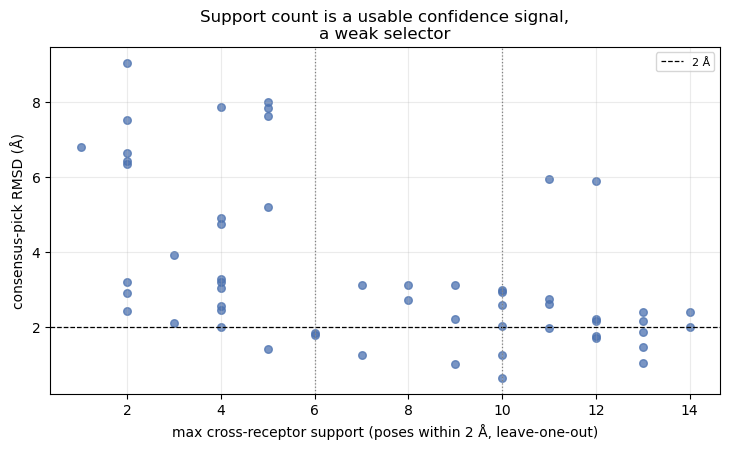

In [15]:
# ── Cross-receptor consensus: full 8x8 CRY1 grid, leave-one-out ─────────────
cons_scores = load(CRY / "consensus_scores.json")
sup = np.array([e["max_support"] for e in cons_scores], float)
cnn = np.array([e["cnn"] for e in cons_scores], float)
con = np.array([e["consensus"] for e in cons_scores], float)

print(f"8x8 CRY1 grid, self-docking cells EXCLUDED so the crystal pose cannot leak")
print(f"into the vote: {len(cons_scores)} query pairs, "
      f"{sorted({e['n_voters'] for e in cons_scores})} voters")
print("─" * 84)
print(f"{'stratum':<22}{'n':>5}{'CNN rank-1':>22}{'consensus':>22}{'p':>9}")
STRATA = [("all", sup >= 0), ("max support >= 6", sup >= 6),
          ("max support >= 10", sup >= 10), ("max support < 6", sup < 6)]
for label, mask in STRATA:
    if mask.sum() < 3:
        continue
    a, b = cnn[mask], con[mask]
    _, _, p = paired(a, b)
    print(f"{label:<22}{int(mask.sum()):>5}"
          f"{f'{a.mean():.2f} A ({int((a < SUB2).sum())}/{int(mask.sum())})':>22}"
          f"{f'{b.mean():.2f} A ({int((b < SUB2).sum())}/{int(mask.sum())})':>22}"
          f"{p:>9.3f}")

if HAVE_SCIPY:
    rho, p = stats.spearmanr(sup, con)
    print(f"\n  Spearman(support count, consensus-pose RMSD) = {rho:+.3f}, p = {p:.2g}")
    hi = sup >= 10
    lo = sup < 6
    print(f"  correct pose (<2 A) at high support (>=10): "
          f"{(con[hi] < SUB2).mean() * 100:.0f}%")
    print(f"  correct pose (<2 A) at low support  (<6)  : "
          f"{(con[lo] < SUB2).mean() * 100:.0f}%")

print("""
  Unstratified this is NOT significant. Stratified it is, and the support count is
  a genuine confidence metric -- poses that recur across receptor conformations are
  better poses.

  READ THE EFFECT CORRECTLY: consensus mainly AVOIDS DISASTERS rather than finding
  right answers. Mean RMSD drops 3.64 -> 2.35 A while the count under 2 A moves
  only 11 -> 12 of 31. It converts 6-8 A picks into 2-3 A picks -- worth having so
  you do not build nonsense FEP edges, but 2-3 A is still not a usable binding mode.

  Practical consequence: on a plastic target like CRY, ensemble docking (several
  receptor conformations) is NECESSARY rather than optional -- not to pick the right
  receptor (there are no discrete states to pick from) but to get a per-pose
  confidence number that nothing else here provides.
""")

if HAVE_MPL:
    fig, ax = plt.subplots(figsize=(7.4, 4.6))
    ax.scatter(sup, con, s=30, alpha=0.75, color="#4C72B0")
    ax.axhline(SUB2, ls="--", color="k", lw=0.9, label=f"{SUB2:.0f} Å")
    for thr in (6, 10):
        ax.axvline(thr, ls=":", color="grey", lw=0.9)
    ax.set_xlabel("max cross-receptor support (poses within 2 Å, leave-one-out)")
    ax.set_ylabel("consensus-pick RMSD (Å)")
    ax.set_title("Support count is a usable confidence signal,\na weak selector")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

---
## 7 · Caveats — including one the earlier write-ups do not state

### ⚠ New caveat: the CRY hydrated receptors came from **smoke-profile** GCMC runs

The three CRY hosts (`csbrt-run/endpoint/{6kx5,7d0m,7dli}`) were run with
`PROFILE=smoke`, not the canonical schedule. Verified from their
`pipeline_audit.json` and stage outputs:

| Quantity | CRY hosts (smoke) | canonical `full` |
|---|---|---|
| UVT1 CSV records / last step | 2 / step 10 | 5 / step 500 |
| NPT steps | 500 | 1,000,000 |
| UVT2 steps | 200 | 250,000 |
| production frames | **3** | 2,500 |
| physical water observations in the density analysis | 2 / 16 / 17 | tens of thousands |

The hydrated CRY receptors therefore carry waters from a **3-frame** trajectory
whose GCMC never received anything close to the canonical attempt counts. Their
9/15/16 kept waters are essentially the solvated-then-barely-equilibrated crystal
waters.

**What this does and does not change.** The *paired* dry-vs-hydrated contrast is
still valid — both arms share the same receptor — so "hydration did not help CRY"
stands as a statement about *those* receptors. But the structural explanation
("the CRY pocket only holds 9–16 waters, against ~98 for EV71") is **confounded**:
EV71's ~98 came from full 10 ns runs. Part of that gap is undersampling, not
pocket chemistry. **The CRY hydration arm should be repeated with `PROFILE=full`
hosts before the structural explanation is relied on.**

The EV71 experiments are unaffected — those medoid frames come from the audited
`full_ludovic_schedule` 32 × 6 matrix (notebook 05).

### Other caveats

- **CRY ground truth needs a two-hop mapping** (guest crystal → host crystal →
  host production, ~0.5–1.6 Å residual per hop), which inflates the absolute
  RMSDs. The paired dry-vs-hydrated contrast is unaffected since both arms share
  the reference.
- **n = 13 for CRY.** CRY entries are mouse Cry1/Cry2; the pocket is conserved
  across mammals.
- **Docking quality is already good on EV71**: 1.5 Å median vs crystal, 25–26/32
  under 2 Å. There is no first-order pose problem to fix.
- **The scaffold gate needs a congeneric series** with a real MCS, and 11 positives
  is a small sample.

### Training-data contamination: very likely clean

GNINA 1.3.2's built-in CNN models are all CrossDocked-derived
(`crossdock_default2018*`, `dense*`, `default2017`) — PDB data through ~2020. The
A71EV2A complexes carry processing dates from 11-SEP-23 to 09-AUG-25 and come from
an ASAP/XChem fragment campaign. These specific ligand complexes cannot be in the
training set.

Caveat: enteroviral 2A protease *structures* predate 2020, so the fold and the apo
receptor may well be represented. That is generalisation, not leakage — but it
means "unseen target" is too strong. **"Unseen complexes and unseen chemotype"** is
right.

### Verification status of the pipeline code itself — do not overstate it

As of 2026-08-03, the pose-exploration scripts were **reported** run against real
data on the local RTX 2080 Ti; the run directories no longer exist, so the numbers
cannot be re-confirmed from disk. Corroborated: `__pycache__` entries for
`dock_poses` and `build_docking_receptor` (cpython-313, 2026-08-03 15:13–15:14)
postdate the GNINA binary install at 15:10.

**Not executed:** the `gcmc_pose` Snakemake rule, the `endpoint_preparation` rule,
and the DAG end-to-end (dry-run only). **A dry-run is not a smoke test.**

---
## 8 · Recap

**The headline.** GCMC waters improve docking agreement with the MD frame the
waters came from (−0.31 Å rank-1, p = 0.028) and not with crystal (+0.04 Å,
p = 0.56). That is circular improvement, measured directly. Never evaluate a
hydrated-docking stage against the frames its waters came from.

**Re-docking cannot create FEP edges.** Both gates are pure chemistry — formal
charge equality and mapped-heavy fraction ≥ 0.50. Anyone proposing pose
exploration as a way to *recover* edges has the mechanism wrong, and should be told
so before GPU time is spent. What pose *does* determine is whether an edge is
**meaningful**: two ligands in different binding modes give a physically empty ΔΔG
however well they map. `screen_fep_edges.py` already records `pose_rmsd_angstrom`
and `centroid_distance_angstrom` but **does not gate on them** — that is the
natural place to make conserved binding position load-bearing.

**What to build instead.** The scaffold-consensus gate: no crystal reference, 7/11
flips caught with zero false positives, including all six severe inversions. It
*removes* meaningless edges.

**Where the effort actually belongs.** The search is essentially solved — oracle is
45/45 sub-2 Å across both crystal benchmarks — while rank-1 is 35/45. In ~22 % of
cases GNINA finds a sub-2 Å pose and then fails to rank it first. **Ranking, not
sampling.** And the cheap immediate win is keeping 3 poses per ligand instead of 1.

**Three things not to do.**

1. Don't quote self-docking as prospective performance. On CRY, self 1.45 Å →
   cross 4.09 Å (p = 0.040).
2. Don't dock into MD/GCMC-derived receptors. Swapping EV71's cognate crystal
   receptor for its MD medoid frame moved rank-1 1.44 → 1.79 Å and oracle
   0.87 → 1.42 Å — a *larger* effect than the difference between two unrelated
   targets.
3. Don't use the CNNscore margin as a confidence signal. Its flip-detection AUC is
   below chance.

**The open item.** Repeat the CRY hydration arm with `PROFILE=full` hosts before
relying on the "CRY pocket is too dry for GCMC to help" explanation (§7).

**Cost control, if this stage is ever enabled.** Endpoint count is multiplicative:
`ligands × round1 × round2`. The shipped config warns 4 × 5 × 3 = 60 endpoints =
**1,770 candidate pairs**. Check that arithmetic before enlarging `ligand_ids`.